# Step 2.1: Delaunay三角剖分 (Delaunay Triangulation)

## 理论背景

### 为什么使用Delaunay三角剖分？

根据Shape Graphs论文（Brandes et al., 2025），Delaunay三角剖分是构建鲁棒图表示的基础。

### 本notebook目标

1. 加载Step 1.4的缩放后数据
2. 对单帧数据构建Delaunay三角剖分
3. 可视化三角剖分结果
4. 分析三角剖分的基本属性
5. 为Step 2.2的角度稳定性剪枝做准备

## 1. 导入库和配置

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import networkx as nx
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

GAME_ID = 10517
HOME_TEAM_ID = '364'
DATA_DIR = Path('../../data/morph_test')
INPUT_FILE = DATA_DIR / f'tracking_data_{GAME_ID}_scaled.parquet'
OUTPUT_DIR = DATA_DIR / 'shape_graphs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"配置完成")

配置完成


## 2. 加载数据

In [2]:
tracking_pl = pl.read_parquet(INPUT_FILE)
print(f"数据加载完成: {len(tracking_pl):,} 行")
tracking_pl.head()

数据加载完成: 2,966,182 行


period_id,timestamp,frame_id,ball_state,id,x,y,z,team_id,position_name,game_id,vx,vy,vz,v,ax,ay,az,a,ball_owning_team_id,is_ball_carrier,attack_intent,defense_intent,tactical_label,x_scaled,y_scaled
i64,duration[μs],i64,str,str,f64,f64,f64,str,str,i32,f64,f64,f64,f64,f64,f64,f64,f64,str,bool,str,str,str,f64,f64
1,821µs,4630,"""alive""","""113""",0.763,-18.099,0.0,"""363""","""ST""",10517,-2.287401,-0.437484,0.0,2.328862,0.0,0.0,0.0,0.0,"""363""",false,"""ATTACKING_PLAY""","""MID_BLOCK""","""ATTACKING_PLAY_MID_BLOCK""",-36.547596,-23.404894
1,821µs,4630,"""alive""","""1532""",0.989,30.929,0.0,"""363""","""RW""",10517,-1.432996,-0.793163,0.0,1.63786,0.0,0.0,0.0,0.0,"""363""",false,"""ATTACKING_PLAY""","""MID_BLOCK""","""ATTACKING_PLAY_MID_BLOCK""",-36.01083,34.0
1,821µs,4630,"""alive""","""1534""",0.421,1.593,0.0,"""363""","""AM""",10517,-1.162497,-0.485199,0.0,1.259689,0.0,0.0,0.0,0.0,"""363""",true,"""ATTACKING_PLAY""","""MID_BLOCK""","""ATTACKING_PLAY_MID_BLOCK""",-37.359871,-0.348331
1,821µs,4630,"""alive""","""1675""",21.242,7.533,0.0,"""363""","""RCB""",10517,-1.028489,-0.62013,0.0,1.200979,0.0,0.0,0.0,0.0,"""363""",false,"""ATTACKING_PLAY""","""MID_BLOCK""","""ATTACKING_PLAY_MID_BLOCK""",12.091488,6.606574
1,821µs,4630,"""alive""","""1789""",18.203,24.9,0.0,"""363""","""RB""",10517,-1.104405,-0.907977,0.0,1.429732,0.0,0.0,0.0,0.0,"""363""",false,"""ATTACKING_PLAY""","""MID_BLOCK""","""ATTACKING_PLAY_MID_BLOCK""",4.873646,26.940889


## 3. 选择测试帧

In [3]:
period_1_frames = tracking_pl.filter(pl.col('period_id') == 1)['frame_id'].unique().sort()
test_frame_id = period_1_frames[len(period_1_frames) // 2]
print(f"测试帧: {test_frame_id}")

测试帧: 55484


## 4. 构建Delaunay三角剖分

In [4]:
frame_data = tracking_pl.filter(
    (pl.col('frame_id') == test_frame_id) &
    (pl.col('team_id') == HOME_TEAM_ID) &
    (pl.col('id').is_not_null()) &
    (~pl.col('id').str.contains('GK'))
).to_pandas()

positions = frame_data[['x', 'y']].values
tri = Delaunay(positions)

print(f"球员数: {len(positions)}")
print(f"三角形数: {len(tri.simplices)}")

球员数: 11
三角形数: 16


## 5. 可视化

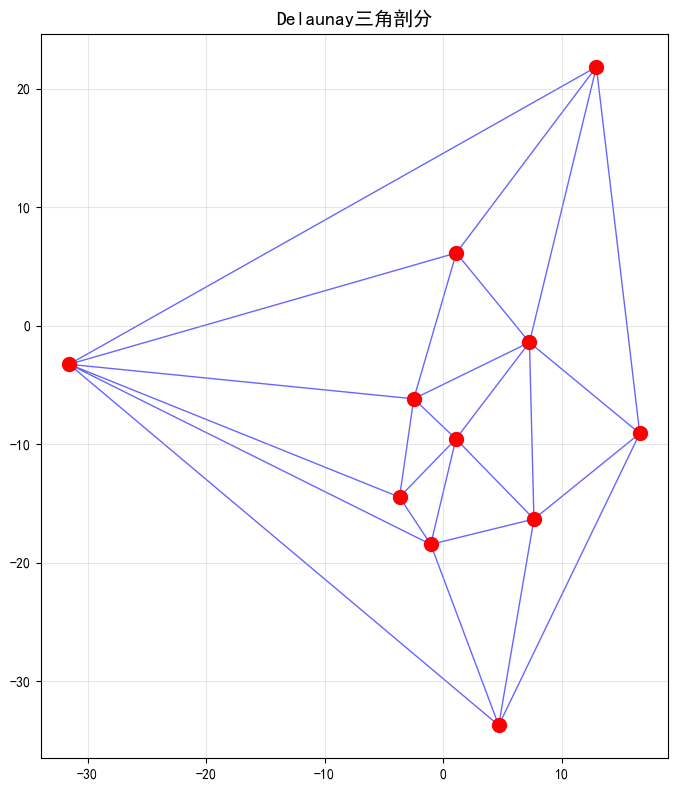

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.triplot(positions[:, 0], positions[:, 1], tri.simplices, 'b-', linewidth=1, alpha=0.6)
ax.plot(positions[:, 0], positions[:, 1], 'ro', markersize=10)
ax.set_title('Delaunay三角剖分', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 6. 总结

本notebook完成了Delaunay三角剖分的基础实现。

下一步：在2.2 notebook中实现角度稳定性剪枝算法。